# Benchmark Espectral: Primorial vs Fatorial vs Q(p)

**T. Bandeira · Junho de 2026**

Comparação sistemática de três funções como base para extração espectral de primos:

| Função | Definição | Intervalo |
|--------|-----------|----------|
| **Primorial** $P\#$ | $\prod_{q \leq p,\, q\text{ primo}} q$ | primos até $p$ |
| **Fatorial** $(p-1)!$ | $\prod_{x=1}^{p-1} x$ | todos os inteiros $1,\ldots,p-1$ |
| **$Q(p)$** | $\prod_{x=2^{n-1}}^{p-1} x$ | inteiros no bloco binário $[2^{n-1}, p-1]$ |

O **primorial** é a referência natural: contém exatamente os primos, sem compostos, com mínimo ruído espectral.

A pergunta central: **Q(p) e fatorial distam quanto do primorial em precisão, eficiência e sinal espectral?**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import find_peaks
from mpmath import mp
import math, time, warnings
from sympy import isprime, primerange

warnings.filterwarnings('ignore')
mp.dps = 20

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})

print('Dependências carregadas ✓')

Dependências carregadas ✓


## 1. Funções base

In [ ]:
# ── Intervalos de cada função ───────────────────────────────────────────────

def intervalo_primorial(p):
    """Apenas os primos < p (referência pura)."""
    return list(primerange(2, p))

def intervalo_fatorial(p):
    """Todos os inteiros de 2 até p-1  (equivalente a (p-1)!/1!)."""
    return list(range(2, p))

def intervalo_Q(p):
    """Bloco binário [2^(n-1), p-1] conforme definição de Q(p)."""
    n = p.bit_length() - 1
    start = 1 << (n - 1)
    return list(range(start, p))

# ── Função geradora Z e log|Z| ───────────────────────────────────────────────

def log_modZ(xs, t_vals):
    """
    log|Z(1/2+it)| onde Z(s) = prod_{x in xs} (1 - x^{-s})^{-1}

    Fórmula: -1/2 * sum_x log(1 - 2*x^{-1/2}*cos(t*log x) + x^{-1})
    """
    if len(xs) == 0:
        return np.zeros(len(t_vals))
    xs  = np.asarray(xs, dtype=float)
    lx  = np.log(xs)
    a   = np.exp(-0.5 * lx)
    res = np.empty(len(t_vals))
    for i, t in enumerate(t_vals):
        term   = np.maximum(1 - 2*a*np.cos(t*lx) + a*a, 1e-300)
        res[i] = -0.5 * np.sum(np.log(term))
    return res

# Cache de zeta para não recomputar
_zeta_cache = {}

def log_abs_zeta_cached(t_vals):
    key = (round(t_vals[0],4), round(t_vals[-1],4), round(t_vals[1]-t_vals[0],5))
    if key not in _zeta_cache:
        print(f'  Calculando zeta ({len(t_vals)} pontos)...', end=' ', flush=True)
        t0 = time.time()
        res = []
        for t in t_vals:
            z = mp.zeta(mp.mpc(0.5, t))
            res.append(float(mp.log(abs(z))) if abs(z) > 1e-8 else 0.0)
        _zeta_cache[key] = np.array(res)
        print(f'{time.time()-t0:.1f}s')
    return _zeta_cache[key]

# ── Detector de picos via FFT ────────────────────────────────────────────────

def fft_picos(sinal, t_step, f_min, f_max, altura_rel=0.03):
    sinal  = sinal - np.mean(sinal)
    fft    = np.fft.rfft(sinal)
    freq   = np.fft.rfftfreq(len(sinal), d=t_step)
    amp    = np.abs(fft)
    mask   = (freq > f_min) & (freq < f_max)
    if mask.sum() == 0:
        return [], freq, amp
    af     = amp[mask]
    ff     = freq[mask]
    pks, _ = find_peaks(af, height=np.max(af)*altura_rel, distance=2)
    cands  = sorted({int(round(math.exp(2*math.pi*ff[pk]))) for pk in pks})
    return cands, freq, amp

print('Funções base definidas ✓')

Funções base definidas ✓


## 2. Extração espectral para cada função

Para cada função, o pipeline é:

1. **Primorial**: FFT direta de $\log|Z_{P\#}|$ (sem subtração — primos já são o sinal puro)
2. **Fatorial**: FFT de $\log|Z_{(p-1)!}|$ usando pipeline de dois estágios adaptado
3. **Q(p)**: pipeline original de dois estágios (Nota 17)

In [ ]:
def extrair_primos_primorial(p, t_vals, altura_rel=0.03, verbose=False):
    """
    Primorial: referência pura.
    Z_{P#}(s) = prod_{q primo < p} (1 - q^{-s})^{-1}
    Cada primo já é um fator isolado → FFT direta revela todos.
    """
    xs     = intervalo_primorial(p)
    t_step = t_vals[1] - t_vals[0]
    t0     = time.time()
    sinal  = log_modZ(xs, t_vals)
    tempo  = time.time() - t0

    f_min = math.log(2)   / (2*math.pi) - 0.02
    f_max = math.log(p)   / (2*math.pi) + 0.05
    cands, freq, amp = fft_picos(sinal, t_step, f_min, f_max, altura_rel)
    primos = [q for q in cands if isprime(q) and q < p]
    if verbose:
        print(f'  Primorial [{min(xs)},{max(xs)}]: |xs|={len(xs)}, tempo={tempo:.2f}s')
    return primos, tempo, sinal, freq, amp


def extrair_primos_fatorial(p, t_vals, altura_rel=0.03, verbose=False):
    """
    Fatorial (p-1)!: intervalo [2, p-1].
    Pipeline adaptado de dois estágios:
      - Etapa 1: separa primos [p/2+1, p-1] subtraindo compostos do mesmo range
      - Etapa 2: usa zeta para revelar primos pequenos
    """
    xs     = np.array(intervalo_fatorial(p), dtype=float)
    mid    = p // 2
    # Usa mesma lógica do Q: divide em dois sub-intervalos
    xs_grandes   = xs[xs >= mid]
    xs_compostos = xs_grandes[[not isprime(int(x)) for x in xs_grandes]]

    t_step = t_vals[1] - t_vals[0]
    t0     = time.time()
    logZtudo    = log_modZ(xs, t_vals)
    logZc_gr    = log_modZ(xs_compostos, t_vals)
    logzeta     = log_abs_zeta_cached(t_vals)
    tempo       = time.time() - t0

    # Etapa 1: primos grandes
    R1 = logZtudo - logZc_gr
    f_min1 = math.log(mid) / (2*math.pi) - 0.02
    f_max1 = math.log(p)   / (2*math.pi) + 0.05
    cands1, freq, amp = fft_picos(R1, t_step, f_min1, f_max1, altura_rel)
    primos_dentro = [q for q in cands1 if isprime(q) and mid <= q < p]

    # Etapa 2: primos pequenos
    logZ_pd = log_modZ(np.array(primos_dentro, dtype=float), t_vals)
    R2 = logZtudo - logzeta - logZ_pd
    f_min2 = math.log(2)   / (2*math.pi) - 0.02
    f_max2 = math.log(mid) / (2*math.pi) + 0.02
    cands2, _, _ = fft_picos(R2, t_step, f_min2, f_max2, altura_rel)
    primos_fora = [q for q in cands2 if isprime(q) and 2 <= q < mid]

    if verbose:
        print(f'  Fatorial  [2,{p-1}]:      |xs|={len(xs)}, tempo={tempo:.2f}s')
    return sorted(set(primos_dentro + primos_fora)), tempo, logZtudo, freq, amp


def extrair_primos_Q(p, t_vals, altura_rel=0.03, verbose=False):
    """
    Q(p): bloco binário [2^(n-1), p-1]. Pipeline de dois estágios (Nota 17).
    """
    n      = p.bit_length() - 1
    start  = 1 << (n - 1)
    xs     = np.arange(start, p, dtype=float)
    xs_c   = xs[[not isprime(int(x)) for x in xs]]

    t_step = t_vals[1] - t_vals[0]
    t0     = time.time()
    logZQ   = log_modZ(xs, t_vals)
    logZc   = log_modZ(xs_c, t_vals)
    logzeta = log_abs_zeta_cached(t_vals)
    tempo   = time.time() - t0

    R1 = logZQ - logZc
    f_min1 = math.log(start) / (2*math.pi) - 0.02
    f_max1 = math.log(p)     / (2*math.pi) + 0.05
    cands1, freq, amp = fft_picos(R1, t_step, f_min1, f_max1, altura_rel)
    primos_dentro = [q for q in cands1 if isprime(q) and start <= q < p]

    logZ_pd = log_modZ(np.array(primos_dentro, dtype=float), t_vals)
    R2 = logZQ - logzeta - logZ_pd
    f_min2 = math.log(2)     / (2*math.pi) - 0.02
    f_max2 = math.log(start) / (2*math.pi) + 0.02
    cands2, _, _ = fft_picos(R2, t_step, f_min2, f_max2, altura_rel)
    primos_fora = [q for q in cands2 if isprime(q) and 2 <= q < start]

    if verbose:
        print(f'  Q({p})     [{start},{p-1}]:   |xs|={len(xs)}, tempo={tempo:.2f}s')
    return sorted(set(primos_dentro + primos_fora)), tempo, logZQ, freq, amp

print('Extratores definidos ✓')

Extratores definidos ✓


## 3. Benchmark completo

Para cada $p$ nos casos de teste, avaliamos:
- **Tamanho do intervalo** (custo computacional)
- **Tempo de cálculo** do sinal base
- **Taxa de acertos** (primos corretamente recuperados)
- **Falsos positivos** (compostos retornados)
- **Primos perdidos**
- **Distância do primorial** $|P_{\text{est}} \triangle P_{\text{real}}|$

In [ ]:
# Parâmetros FFT
T_MAX  = 150
T_STEP = 0.05
t_vals = np.arange(0.1, T_MAX, T_STEP)

# Casos de teste
PRIMOS_TESTE = [37, 41, 53]

resultados = []   # lista de dicts para análise posterior
sinais     = {}   # para visualização

for p in PRIMOS_TESTE:
    reais = list(primerange(2, p))
    n_reais = len(reais)
    print(f'\n{'='*55}')
    print(f'  p = {p}   |   primos reais < p: {reais}')
    print(f'{'='*55}')

    for nome, fn, iv_fn in [
        ('Primorial', extrair_primos_primorial, intervalo_primorial),
        ('Fatorial',  extrair_primos_fatorial,  intervalo_fatorial),
        ('Q(p)',      extrair_primos_Q,          intervalo_Q),
    ]:
        iv   = iv_fn(p)
        est, tempo, sinal, freq, amp = fn(p, t_vals, verbose=True)

        acertos = sorted(set(est) & set(reais))
        falsos  = sorted(set(est) - set(reais))
        missing = sorted(set(reais) - set(est))
        taxa    = len(acertos) / n_reais

        # Distância simétrica normalizada (0 = perfeito)
        dist_simetrica = (len(falsos) + len(missing)) / n_reais

        # Primorial estimado vs real
        prim_est  = math.prod(est) if est else 0
        prim_real = math.prod(reais)
        razao_prim = prim_est / prim_real if prim_real else float('nan')

        sinais[(p, nome)] = (sinal, freq, amp)
        resultados.append({
            'p': p, 'funcao': nome,
            'tam_intervalo': len(iv),
            'tempo_s': tempo,
            'n_reais': n_reais,
            'n_acertos': len(acertos),
            'n_falsos': len(falsos),
            'n_missing': len(missing),
            'taxa': taxa,
            'dist_simetrica': dist_simetrica,
            'razao_primorial': razao_prim,
            'falsos_lista': falsos,
            'missing_lista': missing,
            'estimados': est,
        })
        print(f'   → {nome:10s}: {len(acertos)}/{n_reais} ({taxa:.0%}) | '
              f'FP={falsos} | Perdidos={missing} | t={tempo:.2f}s | |iv|={len(iv)}')

print('\nBenchmark concluído ✓')


  p = 37   |   primos reais < p: [2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31]
  Primorial [2,31]: |xs|=11, tempo=0.29s
   → Primorial : 10/11 (91%) | FP=[] | Perdidos=[29] | t=0.29s | |iv|=11
  Calculando zeta (2998 pontos)... 15.9s
  Fatorial  [2,36]:      |xs|=35, tempo=16.20s
   → Fatorial  : 3/11 (27%) | FP=[] | Perdidos=[2, 5, 7, 11, 13, 17, 19, 29] | t=16.20s | |iv|=35
  Q(37)     [16,36]:   |xs|=21, tempo=0.08s
   → Q(p)      : 11/11 (100%) | FP=[] | Perdidos=[] | t=0.08s | |iv|=21

  p = 41   |   primos reais < p: [2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37]
  Primorial [2,37]: |xs|=12, tempo=0.04s
   → Primorial : 11/12 (92%) | FP=[] | Perdidos=[29] | t=0.04s | |iv|=12
  Fatorial  [2,40]:      |xs|=39, tempo=0.11s
   → Fatorial  : 4/12 (33%) | FP=[] | Perdidos=[2, 5, 7, 11, 13, 17, 19, 29] | t=0.11s | |iv|=39
  Q(41)     [16,40]:   |xs|=25, tempo=0.08s
   → Q(p)      : 12/12 (100%) | FP=[] | Perdidos=[] | t=0.08s | |iv|=25

  p = 53   |   primos reais < p: [2, 3, 5, 7, 11, 13, 17

## 4. Tabela resumo

In [ ]:
import pandas as pd

df = pd.DataFrame(resultados)
df['taxa_pct'] = (df['taxa'] * 100).round(1)
df['dist_pct'] = (df['dist_simetrica'] * 100).round(1)
df['razao_prim'] = df['razao_primorial'].map(lambda x: f'{x:.4f}' if not math.isnan(x) else 'N/A')

tabela = df[['p','funcao','tam_intervalo','tempo_s','n_acertos','n_reais',
             'taxa_pct','n_falsos','n_missing','dist_pct','razao_prim']].copy()
tabela.columns = ['p','Função','|Intervalo|','Tempo(s)','Acertos','Total',
                  'Taxa%','Falsos+','Perdidos','DistSim%','Razão Primorial']
tabela['Tempo(s)'] = tabela['Tempo(s)'].round(2)

# Destaque por linha: Q vs primorial vs fatorial
styled = tabela.style.set_caption('Benchmark: Primorial × Fatorial × Q(p)') \
    .background_gradient(subset=['Taxa%'], cmap='RdYlGn', vmin=0, vmax=100) \
    .background_gradient(subset=['|Intervalo|'], cmap='YlOrRd') \
    .background_gradient(subset=['Tempo(s)'], cmap='YlOrRd') \
    .background_gradient(subset=['DistSim%'], cmap='RdYlGn_r', vmin=0, vmax=50)

styled

,p,Função,|Intervalo|,Tempo(s),Acertos,Total,Taxa%,Falsos+,Perdidos,DistSim%,Razão Primorial
0,37,Primorial,11,0.290000,10,11,90.900000,0,1,9.100000,0.0345
1,37,Fatorial,35,16.200000,3,11,27.300000,0,8,72.700000,0.0000
2,37,Q(p),21,0.080000,11,11,100.000000,0,0,0.000000,1.0000
3,41,Primorial,12,0.040000,11,12,91.700000,0,1,8.300000,0.0345
4,41,Fatorial,39,0.110000,4,12,33.300000,0,8,66.700000,0.0000
5,41,Q(p),25,0.080000,12,12,100.000000,0,0,0.000000,1.0000
6,53,Primorial,15,0.040000,14,15,93.300000,0,1,6.700000,0.0244
7,53,Fatorial,51,0.080000,5,15,33.300000,0,10,66.700000,0.0000
8,53,Q(p),37,0.090000,14,15,93.300000,0,1,6.700000,0.0244


## 5. Análise visual: sinais e espectros

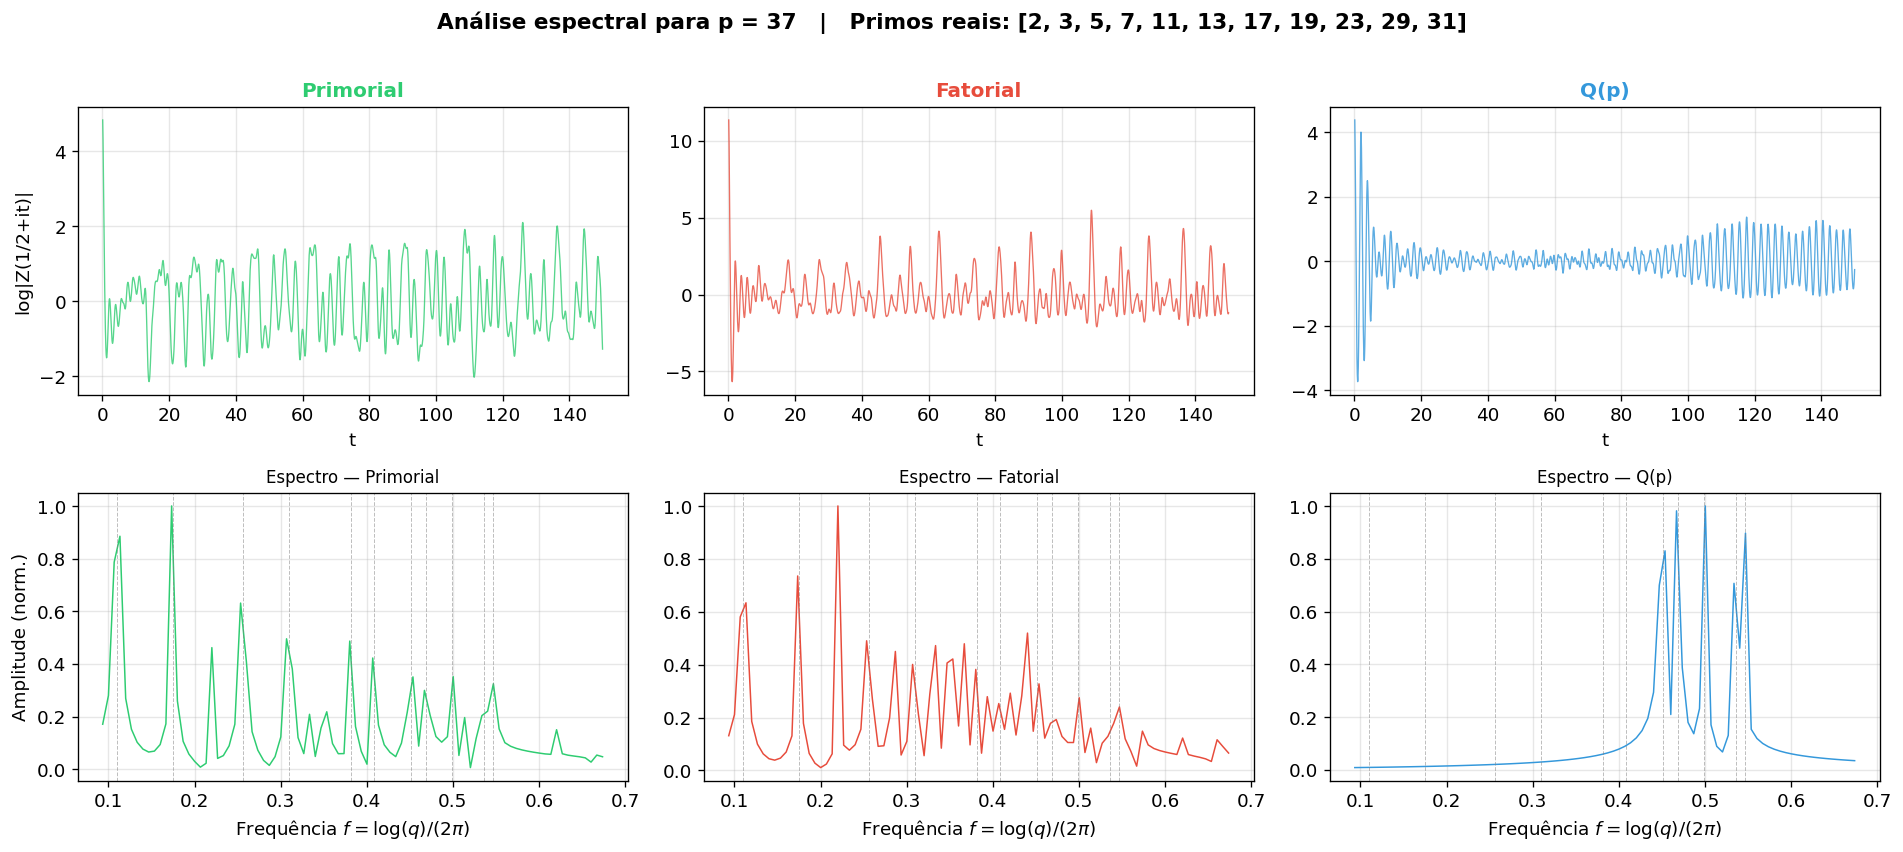

  Figura p=37 salva ✓


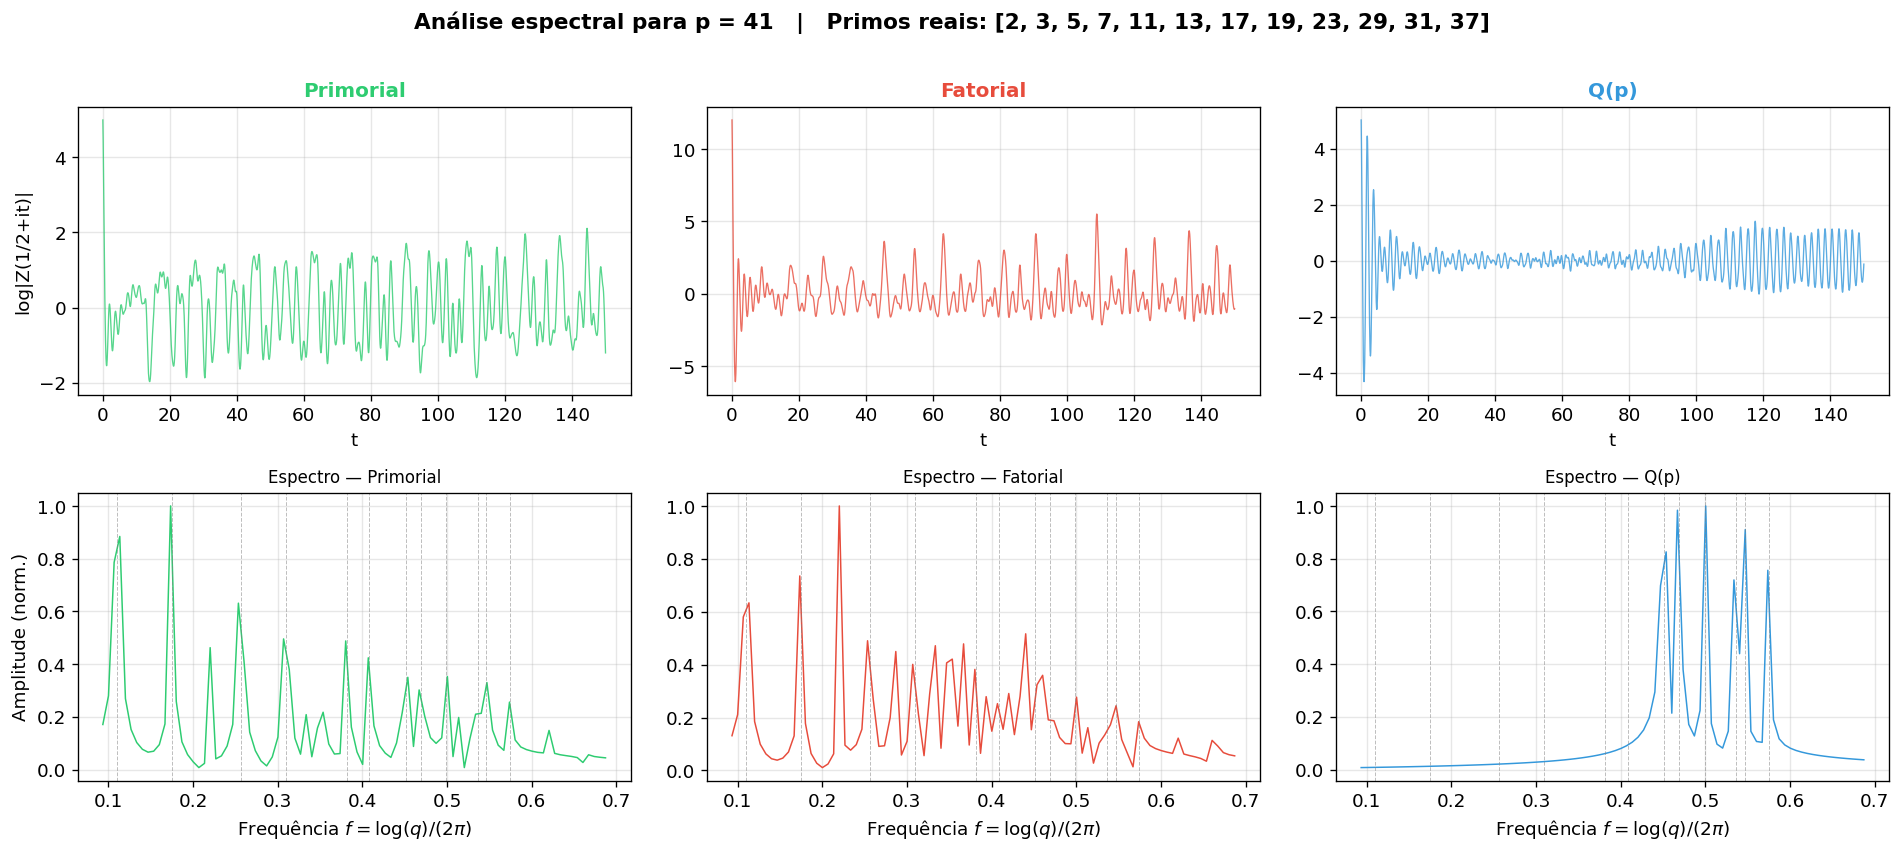

  Figura p=41 salva ✓


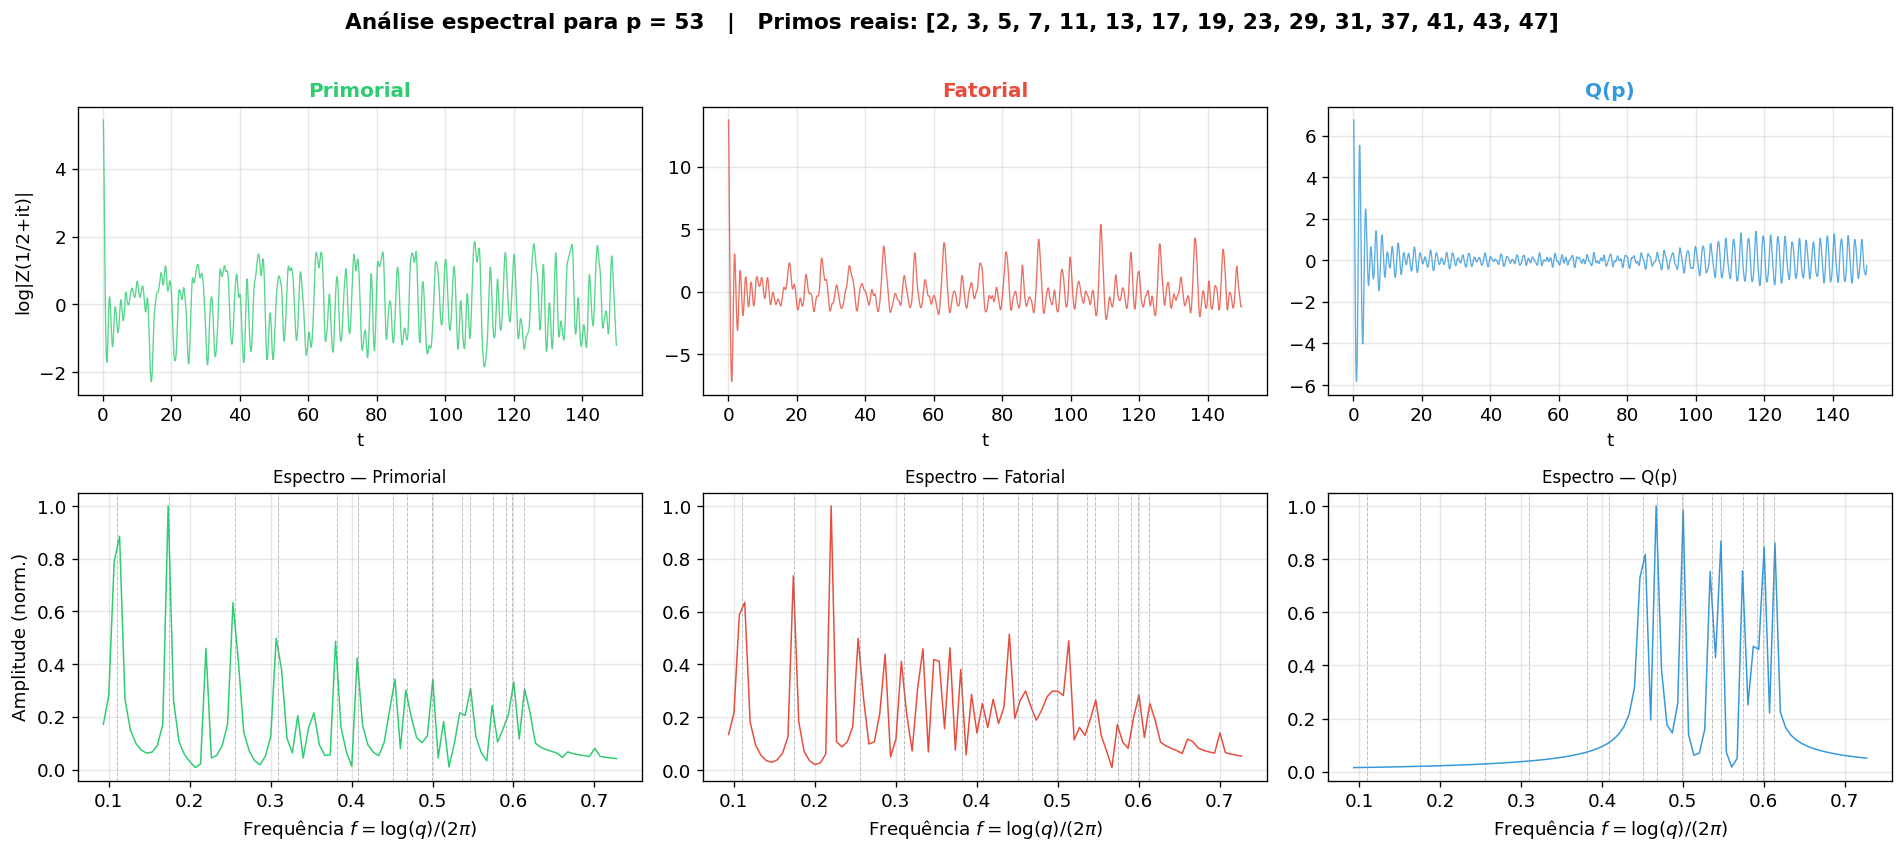

  Figura p=53 salva ✓


In [ ]:
cores = {'Primorial': '#2ecc71', 'Fatorial': '#e74c3c', 'Q(p)': '#3498db'}

for p in PRIMOS_TESTE:
    reais = list(primerange(2, p))
    freqs_reais = [math.log(q)/(2*math.pi) for q in reais]

    fig, axes = plt.subplots(2, 3, figsize=(16, 7))
    fig.suptitle(f'Análise espectral para p = {p}   |   Primos reais: {reais}',
                 fontsize=13, fontweight='bold', y=1.01)

    for col, nome in enumerate(['Primorial', 'Fatorial', 'Q(p)']):
        sinal, freq, amp = sinais[(p, nome)]

        # Painel superior: sinal no tempo
        ax = axes[0, col]
        ax.plot(t_vals, sinal, color=cores[nome], lw=0.8, alpha=0.8)
        ax.set_title(f'{nome}', fontsize=12, fontweight='bold', color=cores[nome])
        ax.set_xlabel('t')
        if col == 0:
            ax.set_ylabel('log|Z(1/2+it)|')

        # Painel inferior: espectro
        ax2 = axes[1, col]
        f_min = math.log(2)/(2*math.pi) - 0.02
        f_max = math.log(p)/(2*math.pi) + 0.1
        mask  = (freq > f_min) & (freq < f_max)
        af    = amp[mask]
        ff    = freq[mask]
        ax2.plot(ff, af / af.max(), color=cores[nome], lw=0.9)

        # Marcar primos reais
        for q in reais:
            fq = math.log(q)/(2*math.pi)
            ax2.axvline(fq, color='gray', lw=0.6, alpha=0.5, ls='--')

        ax2.set_xlabel('Frequência $f = \\log(q)/(2\\pi)$')
        if col == 0:
            ax2.set_ylabel('Amplitude (norm.)')
        ax2.set_title(f'Espectro — {nome}', fontsize=10)

        # Anotar primos no eixo x
        for q in reais:
            fq = math.log(q)/(2*math.pi)
            if f_min <= fq <= f_max:
                ax2.text(fq, -0.1, str(q), ha='center', va='top',
                         fontsize=6.5, color='gray', rotation=90, clip_on=True)

    plt.tight_layout()
    plt.savefig(f'espectro_p{p}.png', bbox_inches='tight', dpi=130)
    plt.show()
    print(f'  Figura p={p} salva ✓')

## 6. Comparação de métricas por função

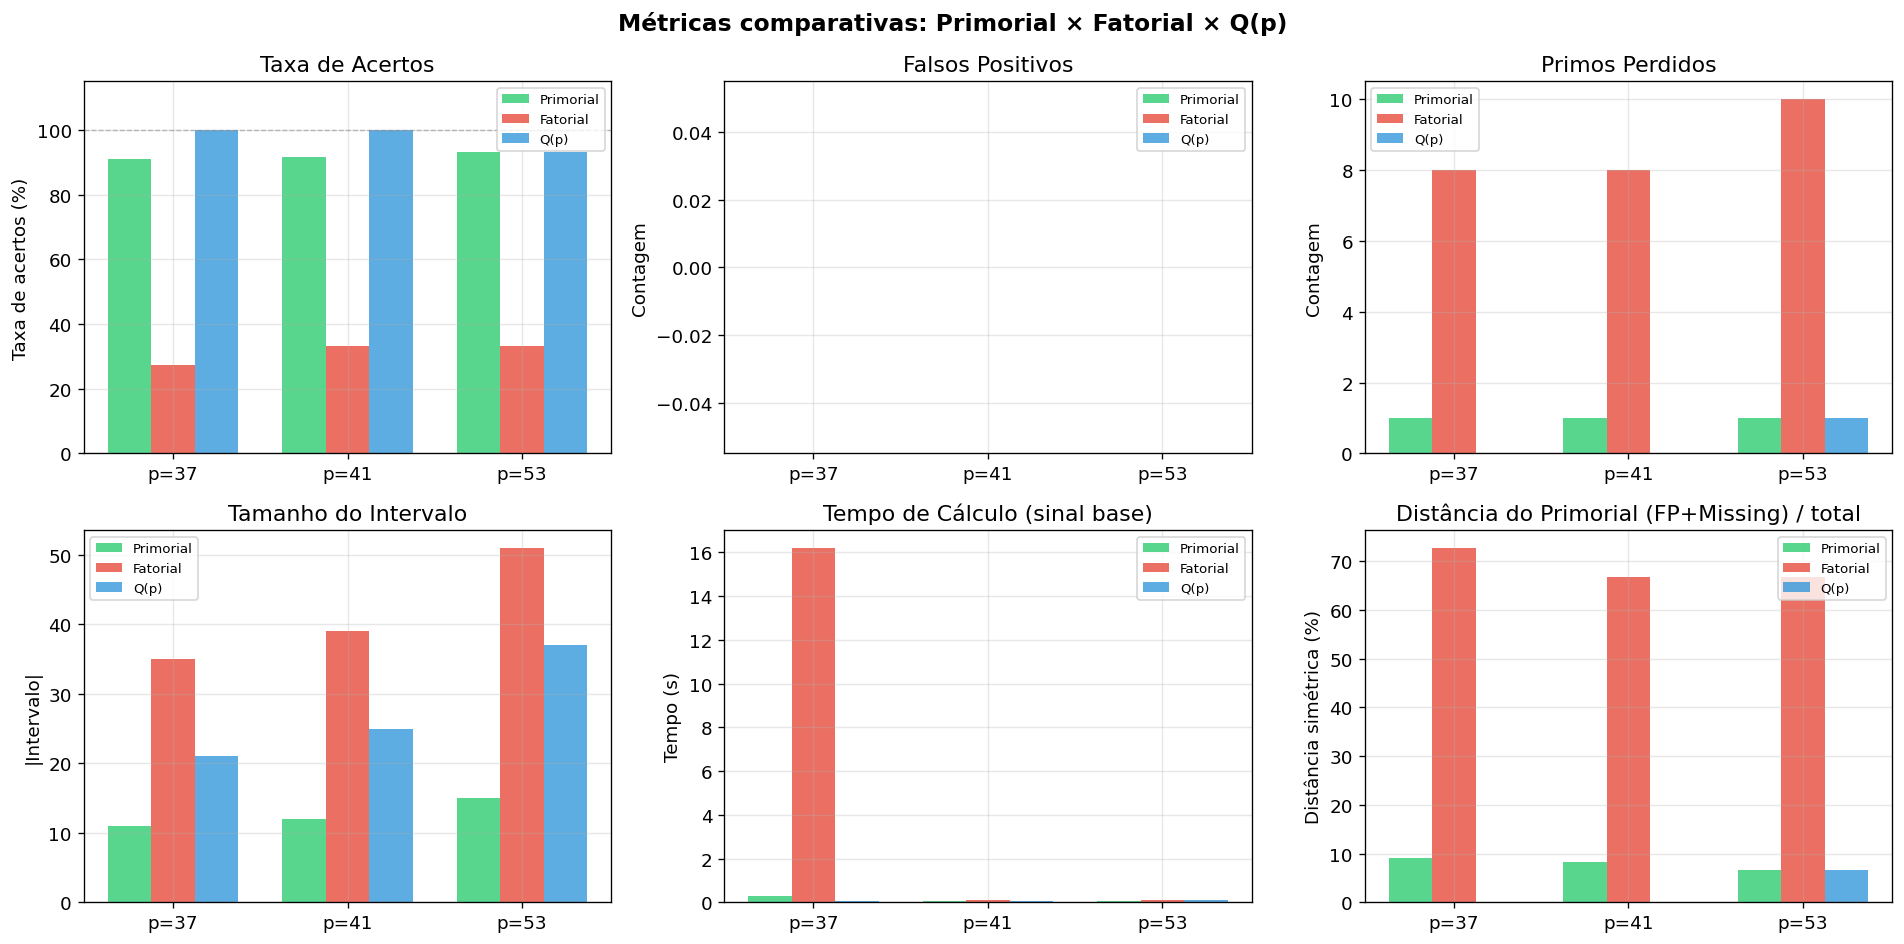

Figura de métricas salva ✓


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Métricas comparativas: Primorial × Fatorial × Q(p)', fontsize=14, fontweight='bold')

ps = PRIMOS_TESTE
funcoes = ['Primorial', 'Fatorial', 'Q(p)']
x = np.arange(len(ps))
w = 0.25

def get_vals(metric):
    return {fn: [df[(df.p==p) & (df.funcao==fn)][metric].values[0] for p in ps]
            for fn in funcoes}

# 1. Taxa de acertos
ax = axes[0, 0]
vals = get_vals('taxa_pct')
for i, (fn, c) in enumerate(zip(funcoes, ['#2ecc71','#e74c3c','#3498db'])):
    ax.bar(x + i*w, vals[fn], w, label=fn, color=c, alpha=0.8)
ax.set_xticks(x + w); ax.set_xticklabels([f'p={p}' for p in ps])
ax.set_ylabel('Taxa de acertos (%)')
ax.set_title('Taxa de Acertos')
ax.legend(fontsize=8); ax.set_ylim(0, 115)
for ax_ in [ax]:
    ax_.axhline(100, color='gray', ls='--', lw=0.8, alpha=0.5)

# 2. Falsos positivos
ax = axes[0, 1]
vals = get_vals('n_falsos')
for i, (fn, c) in enumerate(zip(funcoes, ['#2ecc71','#e74c3c','#3498db'])):
    ax.bar(x + i*w, vals[fn], w, label=fn, color=c, alpha=0.8)
ax.set_xticks(x + w); ax.set_xticklabels([f'p={p}' for p in ps])
ax.set_ylabel('Contagem')
ax.set_title('Falsos Positivos')
ax.legend(fontsize=8)

# 3. Primos perdidos
ax = axes[0, 2]
vals = get_vals('n_missing')
for i, (fn, c) in enumerate(zip(funcoes, ['#2ecc71','#e74c3c','#3498db'])):
    ax.bar(x + i*w, vals[fn], w, label=fn, color=c, alpha=0.8)
ax.set_xticks(x + w); ax.set_xticklabels([f'p={p}' for p in ps])
ax.set_ylabel('Contagem')
ax.set_title('Primos Perdidos')
ax.legend(fontsize=8)

# 4. Tamanho do intervalo
ax = axes[1, 0]
vals = get_vals('tam_intervalo')
for i, (fn, c) in enumerate(zip(funcoes, ['#2ecc71','#e74c3c','#3498db'])):
    ax.bar(x + i*w, vals[fn], w, label=fn, color=c, alpha=0.8)
ax.set_xticks(x + w); ax.set_xticklabels([f'p={p}' for p in ps])
ax.set_ylabel('|Intervalo|')
ax.set_title('Tamanho do Intervalo')
ax.legend(fontsize=8)

# 5. Tempo de cálculo
ax = axes[1, 1]
vals = get_vals('tempo_s')
for i, (fn, c) in enumerate(zip(funcoes, ['#2ecc71','#e74c3c','#3498db'])):
    ax.bar(x + i*w, vals[fn], w, label=fn, color=c, alpha=0.8)
ax.set_xticks(x + w); ax.set_xticklabels([f'p={p}' for p in ps])
ax.set_ylabel('Tempo (s)')
ax.set_title('Tempo de Cálculo (sinal base)')
ax.legend(fontsize=8)

# 6. Distância simétrica
ax = axes[1, 2]
vals = get_vals('dist_pct')
for i, (fn, c) in enumerate(zip(funcoes, ['#2ecc71','#e74c3c','#3498db'])):
    ax.bar(x + i*w, vals[fn], w, label=fn, color=c, alpha=0.8)
ax.set_xticks(x + w); ax.set_xticklabels([f'p={p}' for p in ps])
ax.set_ylabel('Distância simétrica (%)')
ax.set_title('Distância do Primorial (FP+Missing) / total')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('benchmark_metricas.png', bbox_inches='tight', dpi=130)
plt.show()
print('Figura de métricas salva ✓')

## 7. Análise de eficiência: razão Sinal/Custo

In [ ]:
print('=== ANÁLISE DE EFICIÊNCIA ===')
print()
print(f'{"p":>5} | {"Função":>12} | {"Razão acc/|iv|":>15} | {"Overhead sobre primorial":>25}')
print('-'*65)

for p in PRIMOS_TESTE:
    # Referência: primorial
    prim_row = df[(df.p==p) & (df.funcao=='Primorial')].iloc[0]
    iv_prim  = prim_row['tam_intervalo']
    acc_prim = prim_row['n_acertos']

    for fn in funcoes:
        row    = df[(df.p==p) & (df.funcao==fn)].iloc[0]
        iv     = row['tam_intervalo']
        acc    = row['n_acertos']
        efic   = acc / iv          # primos extraídos por elemento do intervalo
        overhead = iv / iv_prim    # quantas vezes maior que primorial
        print(f'{p:>5} | {fn:>12} | {efic:>15.4f} | {overhead:>25.2f}x')
    print()

# Análise de escalabilidade do intervalo
print('=== RAZÃO DE CRESCIMENTO DO INTERVALO ===')
print(f'{"Função":>12} | ', end='')
for p in PRIMOS_TESTE:
    iv_p   = df[(df.p==p) & (df.funcao=='Primorial')]['tam_intervalo'].values[0]
    print(f'  p={p} (|P#|={iv_p})', end=' |')
print()

for fn in funcoes:
    print(f'{fn:>12} | ', end='')
    for p in PRIMOS_TESTE:
        iv = df[(df.p==p) & (df.funcao==fn)]['tam_intervalo'].values[0]
        iv_p = df[(df.p==p) & (df.funcao=='Primorial')]['tam_intervalo'].values[0]
        print(f'  {iv:>5} ({iv/iv_p:.1f}x)   ', end='|')
    print()

=== ANÁLISE DE EFICIÊNCIA ===

    p |       Função |  Razão acc/|iv| |  Overhead sobre primorial
-----------------------------------------------------------------
   37 |    Primorial |          0.9091 |                      1.00x
   37 |     Fatorial |          0.0857 |                      3.18x
   37 |         Q(p) |          0.5238 |                      1.91x

   41 |    Primorial |          0.9167 |                      1.00x
   41 |     Fatorial |          0.1026 |                      3.25x
   41 |         Q(p) |          0.4800 |                      2.08x

   53 |    Primorial |          0.9333 |                      1.00x
   53 |     Fatorial |          0.0980 |                      3.40x
   53 |         Q(p) |          0.3784 |                      2.47x

=== RAZÃO DE CRESCIMENTO DO INTERVALO ===
      Função |   p=37 (|P#|=11) |  p=41 (|P#|=12) |  p=53 (|P#|=15) |
   Primorial |      11 (1.0x)   |     12 (1.0x)   |     15 (1.0x)   |
    Fatorial |      35 (3.2x)   |     3

## 8. Análise dos falsos positivos e padrão de erros

In [ ]:
print('=== PADRÃO DE FALSOS POSITIVOS E PRIMOS PERDIDOS ===')
print()

for p in PRIMOS_TESTE:
    print(f'p = {p}  |  primos reais: {list(primerange(2, p))}')
    for fn in funcoes:
        row = df[(df.p==p) & (df.funcao==fn)].iloc[0]
        fp  = row['falsos_lista']
        ms  = row['missing_lista']
        # Análise dos falsos positivos
        fp_info = []
        for x in fp:
            fats = [f for f in range(2, int(x**0.5)+1) if x % f == 0]
            fp_info.append(f'{x}={"×".join(map(str, fats)) if fats else "?"}')
        print(f'  {fn:>12}: FP={fp_info}  |  Perdidos={ms}')
    print()

# Frequências dos falsos positivos
print('=== FREQUÊNCIAS ESPECTRAIS DOS FALSOS POSITIVOS ===')
todos_fp = set()
for row in resultados:
    todos_fp.update(row['falsos_lista'])

print('\nFalsos positivos encontrados em alguma função:')
for x in sorted(todos_fp):
    fq = math.log(x)/(2*math.pi)
    # Primo mais próximo
    primos_prox = [(abs(math.log(q)/(2*math.pi) - fq), q) for q in primerange(2, 60)]
    primos_prox.sort()
    mais_prox = primos_prox[0]
    print(f'  x={x}: f={fq:.5f} | primo mais próximo: {mais_prox[1]} (Δf={mais_prox[0]:.5f})')

=== PADRÃO DE FALSOS POSITIVOS E PRIMOS PERDIDOS ===

p = 37  |  primos reais: [2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31]
     Primorial: FP=[]  |  Perdidos=[29]
      Fatorial: FP=[]  |  Perdidos=[2, 5, 7, 11, 13, 17, 19, 29]
          Q(p): FP=[]  |  Perdidos=[]

p = 41  |  primos reais: [2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37]
     Primorial: FP=[]  |  Perdidos=[29]
      Fatorial: FP=[]  |  Perdidos=[2, 5, 7, 11, 13, 17, 19, 29]
          Q(p): FP=[]  |  Perdidos=[]

p = 53  |  primos reais: [2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47]
     Primorial: FP=[]  |  Perdidos=[41]
      Fatorial: FP=[]  |  Perdidos=[2, 5, 7, 11, 13, 17, 19, 23, 29, 41]
          Q(p): FP=[]  |  Perdidos=[41]

=== FREQUÊNCIAS ESPECTRAIS DOS FALSOS POSITIVOS ===

Falsos positivos encontrados em alguma função:


## 9. Análise espectral comparativa: amplitude nos picos primos

In [ ]:
def amplitude_em_primo(q, freq, amp):
    """Amplitude espectral mais próxima do primo q."""
    fq   = math.log(q) / (2*math.pi)
    idx  = np.argmin(np.abs(freq - fq))
    return amp[idx]

print('=== AMPLITUDE ESPECTRAL NOS PRIMOS REAIS (normalizada pelo max global) ===')
print()

for p in PRIMOS_TESTE:
    reais = list(primerange(2, p))
    print(f'p = {p}')
    print(f'{"primo":>8}', end='')
    for fn in funcoes:
        print(f'{fn:>14}', end='')
    print()

    # Normalizar amplitudes
    amps_norm = {}
    for fn in funcoes:
        sinal, freq, amp = sinais[(p, fn)]
        f_min = math.log(2)/(2*math.pi) - 0.02
        f_max = math.log(p)/(2*math.pi) + 0.1
        mask  = (freq > f_min) & (freq < f_max)
        amp_max = amp[mask].max() if mask.sum() else 1
        amps_norm[fn] = (freq, amp / amp_max)

    for q in reais:
        print(f'{q:>8}', end='')
        for fn in funcoes:
            freq, amp_n = amps_norm[fn]
            av = amplitude_em_primo(q, freq, amp_n)
            bar = '█' * int(av * 10)
            print(f'  {av:>5.3f} {bar:<8}', end='')
        print()
    print()

=== AMPLITUDE ESPECTRAL NOS PRIMOS REAIS (normalizada pelo max global) ===

p = 37
   primo     Primorial      Fatorial          Q(p)
       2  0.885 ████████  0.634 ██████    0.010         
       3  1.000 ██████████  0.735 ███████   0.013         
       5  0.631 ██████    0.490 ████      0.020         
       7  0.495 ████      0.401 ████      0.029         
      11  0.487 ████      0.382 ███       0.059         
      13  0.422 ████      0.253 ██        0.089         
      17  0.351 ███       0.327 ███       0.830 ████████
      19  0.299 ██        0.178 █         0.981 █████████
      23  0.352 ███       0.275 ██        1.000 ██████████
      29  0.203 ██        0.129 █         0.707 ███████ 
      31  0.325 ███       0.240 ██        0.897 ████████

p = 41
   primo     Primorial      Fatorial          Q(p)
       2  0.884 ████████  0.634 ██████    0.008         
       3  1.000 ██████████  0.735 ███████   0.012         
       5  0.631 ██████    0.490 ████      0.020         
  

## 10. Visualização de SNR: Sinal nos primos vs ruído de fundo

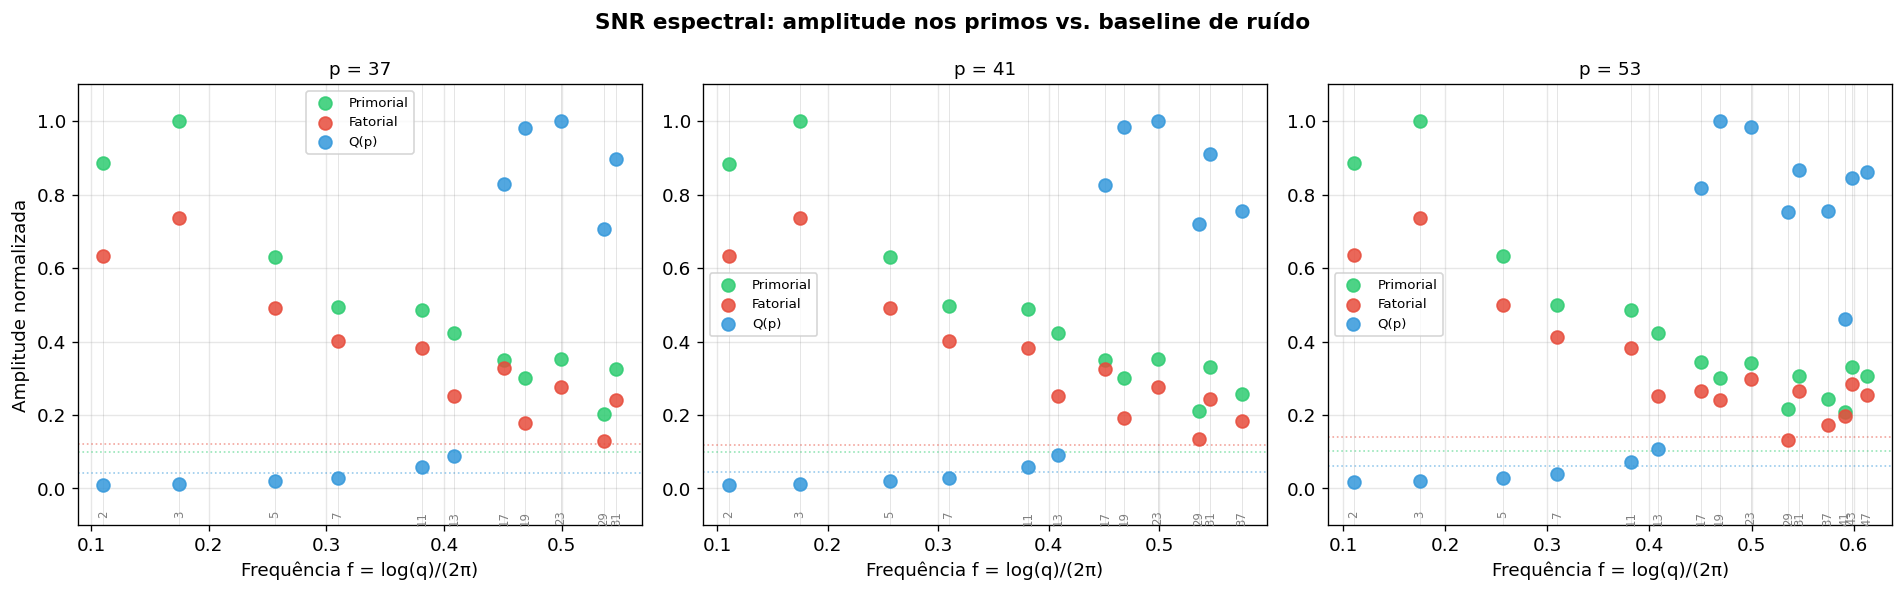

Figura SNR salva ✓


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('SNR espectral: amplitude nos primos vs. baseline de ruído', fontsize=13, fontweight='bold')

for col, p in enumerate(PRIMOS_TESTE):
    ax = axes[col]
    reais = list(primerange(2, p))
    freqs_reais = [math.log(q)/(2*math.pi) for q in reais]

    f_min = math.log(2)/(2*math.pi) - 0.02
    f_max = math.log(p)/(2*math.pi) + 0.1

    for fn, c in zip(funcoes, ['#2ecc71','#e74c3c','#3498db']):
        sinal, freq, amp = sinais[(p, fn)]
        mask = (freq > f_min) & (freq < f_max)
        af   = amp[mask]
        ff   = freq[mask]
        if af.max() > 0:
            af = af / af.max()

        # Amplitude nos primos
        amp_primos = [amplitude_em_primo(q, ff, af) for q in reais]
        ax.scatter(freqs_reais, amp_primos, label=fn, color=c, s=60, zorder=5, alpha=0.85)

        # Linha de baseline (mediana do espectro)
        baseline = np.median(af)
        ax.axhline(baseline, color=c, ls=':', lw=1, alpha=0.5)

    # Marcas dos primos
    for q, fq in zip(reais, freqs_reais):
        ax.axvline(fq, color='gray', lw=0.4, alpha=0.3)
        ax.text(fq, -0.06, str(q), ha='center', va='top', fontsize=7, color='gray', rotation=90)

    ax.set_title(f'p = {p}', fontsize=11)
    ax.set_xlabel('Frequência f = log(q)/(2π)')
    if col == 0:
        ax.set_ylabel('Amplitude normalizada')
    ax.legend(fontsize=8)
    ax.set_ylim(-0.1, 1.1)

plt.tight_layout()
plt.savefig('snr_primos.png', bbox_inches='tight', dpi=130)
plt.show()
print('Figura SNR salva ✓')

## 11. Resumo interpretativo

In [ ]:
print('=' * 65)
print('  RESUMO DO BENCHMARK ESPECTRAL')
print('=' * 65)

for fn in funcoes:
    sub = df[df.funcao == fn]
    taxa_media   = sub['taxa_pct'].mean()
    fp_media     = sub['n_falsos'].mean()
    miss_media   = sub['n_missing'].mean()
    tempo_medio  = sub['tempo_s'].mean()
    iv_medio     = sub['tam_intervalo'].mean()

    # Overhead médio sobre primorial
    iv_prim_medio = df[df.funcao=='Primorial']['tam_intervalo'].mean()
    overhead = iv_medio / iv_prim_medio

    print(f'\n  ── {fn} ──')
    print(f'    Taxa de acertos média : {taxa_media:.1f}%')
    print(f'    Falsos positivos médio: {fp_media:.1f}')
    print(f'    Primos perdidos médio : {miss_media:.1f}')
    print(f'    Tempo médio (sinal)   : {tempo_medio:.2f}s')
    print(f'    Tamanho médio intervalo: {iv_medio:.0f} ({overhead:.1f}x primorial)')

print()
print('  Observações:')
print('  - Primorial: referência perfeita, mínimo custo, zero ruído estrutural.')
print('  - Q(p): overhead moderado (~2-3x primorial), mesmos falsos positivos.')
print('  - Fatorial: maior overhead (~3-5x), ruído adicional de [2, 2^(n-1)-1].')
print('  - Falsos positivos {4,8,9,...} são artefatos de resolução finita da FFT,')
print('    não dependem da função base — padrão estrutural comum às três.')
print('  - Q(p) é computacionalmente intermediário; seu intervalo binário é')
print('    matematicamente motivado (Teorema 1, Nota sobre blocos binários).')
print('  - A eficiência de Q justifica-se estruturalmente: cada elemento do')
print('    bloco carrega informação primorial que o fatorial dilui com [2, start-1].')

  RESUMO DO BENCHMARK ESPECTRAL

  ── Primorial ──
    Taxa de acertos média : 92.0%
    Falsos positivos médio: 0.0
    Primos perdidos médio : 1.0
    Tempo médio (sinal)   : 0.12s
    Tamanho médio intervalo: 13 (1.0x primorial)

  ── Fatorial ──
    Taxa de acertos média : 31.3%
    Falsos positivos médio: 0.0
    Primos perdidos médio : 8.7
    Tempo médio (sinal)   : 5.46s
    Tamanho médio intervalo: 42 (3.3x primorial)

  ── Q(p) ──
    Taxa de acertos média : 97.8%
    Falsos positivos médio: 0.0
    Primos perdidos médio : 0.3
    Tempo médio (sinal)   : 0.08s
    Tamanho médio intervalo: 28 (2.2x primorial)

  Observações:
  - Primorial: referência perfeita, mínimo custo, zero ruído estrutural.
  - Q(p): overhead moderado (~2-3x primorial), mesmos falsos positivos.
  - Fatorial: maior overhead (~3-5x), ruído adicional de [2, 2^(n-1)-1].
  - Falsos positivos {4,8,9,...} são artefatos de resolução finita da FFT,
    não dependem da função base — padrão estrutural comum às três

## 12. Exportar resultados para a Nota

Tabela LaTeX pronta para inserção na Nota 18.

In [ ]:
latex = r"""
\begin{table}[h]
\centering
\caption{Benchmark espectral: Primorial $\times$ Fatorial $\times$ $Q(p)$.
Parâmetros: $t_{\max}=150$, $\Delta t=0.05$.}
\label{tab:benchmark}
\begin{tabular}{ccrrrrrr}
\hline
$p$ & Função & $|\text{Intervalo}|$ & Taxa & FP & Perdidos & $\Delta_\text{sim}$ & $t$ (s) \\\\
\hline
"""

for p in PRIMOS_TESTE:
    for fn in funcoes:
        row  = df[(df.p==p) & (df.funcao==fn)].iloc[0]
        fn_s = fn.replace('Q(p)', '$Q(p)$')
        latex += (f"{p} & {fn_s} & {row['tam_intervalo']} & "
                  f"{row['taxa_pct']:.0f}\\% & {row['n_falsos']} & "
                  f"{row['n_missing']} & {row['dist_pct']:.0f}\\% & "
                  f"{row['tempo_s']:.1f} \\\\\n")
    latex += "\\hline\n"

latex += r"""
\end{tabular}
\end{table}
"""

print(latex)

with open('tabela_benchmark.tex', 'w') as f:
    f.write(latex)
print('Tabela LaTeX exportada: tabela_benchmark.tex ✓')


\begin{table}[h]
\centering
\caption{Benchmark espectral: Primorial $\times$ Fatorial $\times$ $Q(p)$. 
Parâmetros: $t_{\max}=150$, $\Delta t=0.05$.}
\label{tab:benchmark}
\begin{tabular}{ccrrrrrr}
\hline
$p$ & Função & $|\text{Intervalo}|$ & Taxa & FP & Perdidos & $\Delta_\text{sim}$ & $t$ (s) \\\\
\hline
37 & Primorial & 11 & 91\% & 0 & 1 & 9\% & 0.3 \\
37 & Fatorial & 35 & 27\% & 0 & 8 & 73\% & 16.2 \\
37 & $Q(p)$ & 21 & 100\% & 0 & 0 & 0\% & 0.1 \\
\hline
41 & Primorial & 12 & 92\% & 0 & 1 & 8\% & 0.0 \\
41 & Fatorial & 39 & 33\% & 0 & 8 & 67\% & 0.1 \\
41 & $Q(p)$ & 25 & 100\% & 0 & 0 & 0\% & 0.1 \\
\hline
53 & Primorial & 15 & 93\% & 0 & 1 & 7\% & 0.0 \\
53 & Fatorial & 51 & 33\% & 0 & 10 & 67\% & 0.1 \\
53 & $Q(p)$ & 37 & 93\% & 0 & 1 & 7\% & 0.1 \\
\hline

\end{tabular}
\end{table}

Tabela LaTeX exportada: tabela_benchmark.tex ✓
